# 1.2(Optional)_leafcutter2_results_QC

## check the results of leafcutter2
to anwser the question: find a suitable cut off to define a filtering threshold: how many reads shown in how many samples. 

In [31]:
library(purrr)

In [1]:
library(data.table)
library(tidyverse)
nums <- fread("/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind_numers.counts.noise_by_intron.gz")
counts <- fread("/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind.counts.noise_by_intron.gz")

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ pu

In [33]:
df <- nums

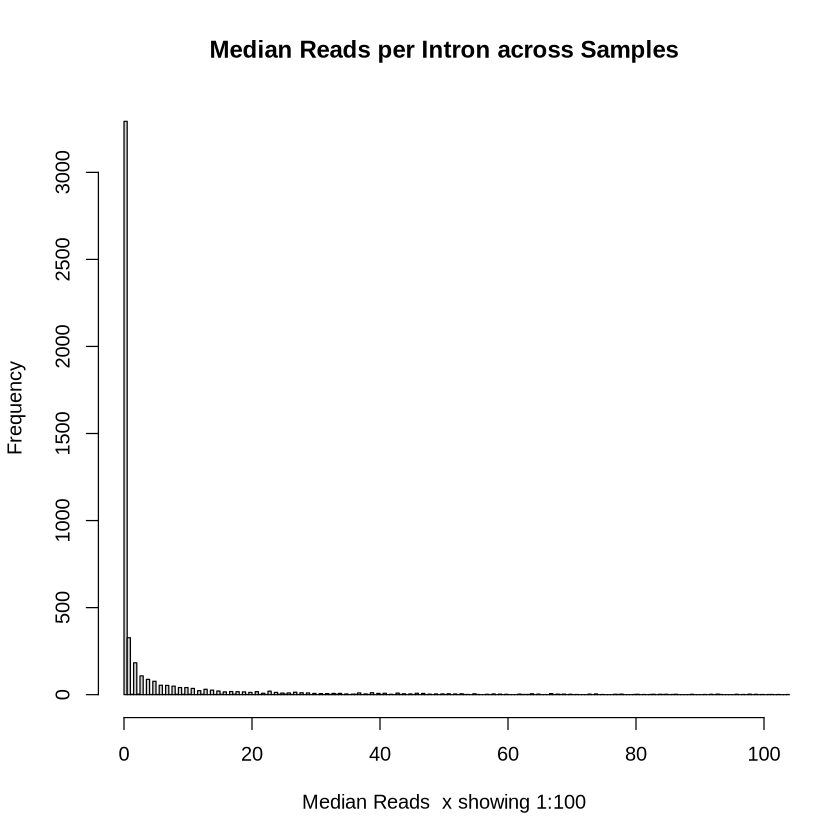

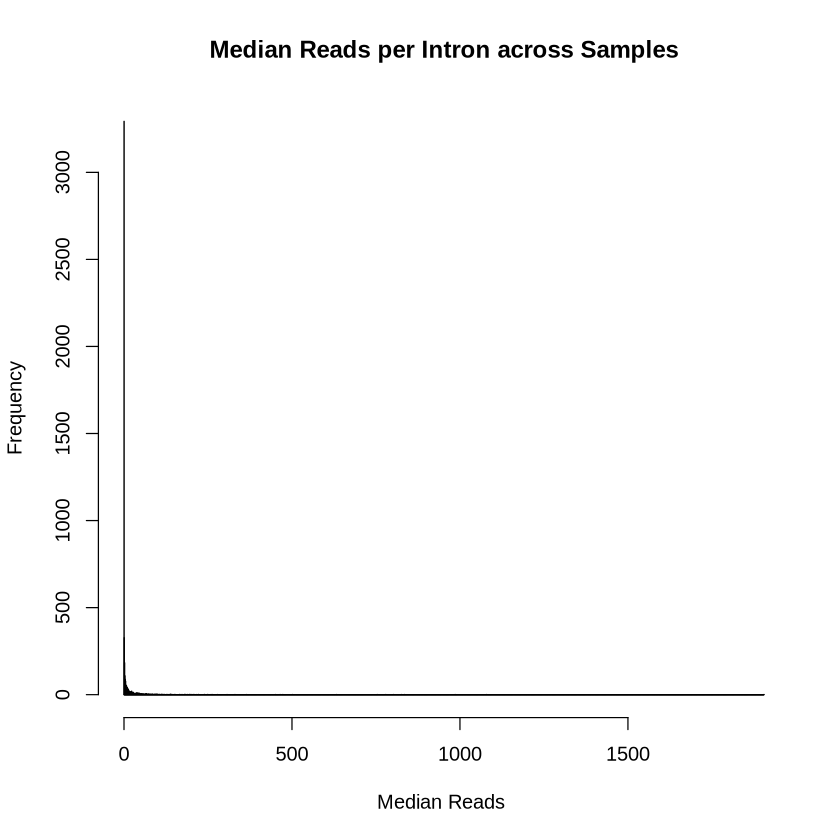

In [34]:
# step1

df_sam <-df %>% 
  select(-1) %>% 
  apply(1, median) %>% sample(.,5000)

hist(df_sam, breaks = 3000, main = "Median Reads per Intron across Samples", xlab = "Median Reads  x showing 1:100", xlim = c(0,100))
hist(df_sam, breaks = 3000, main = "Median Reads per Intron across Samples", xlab = "Median Reads ")

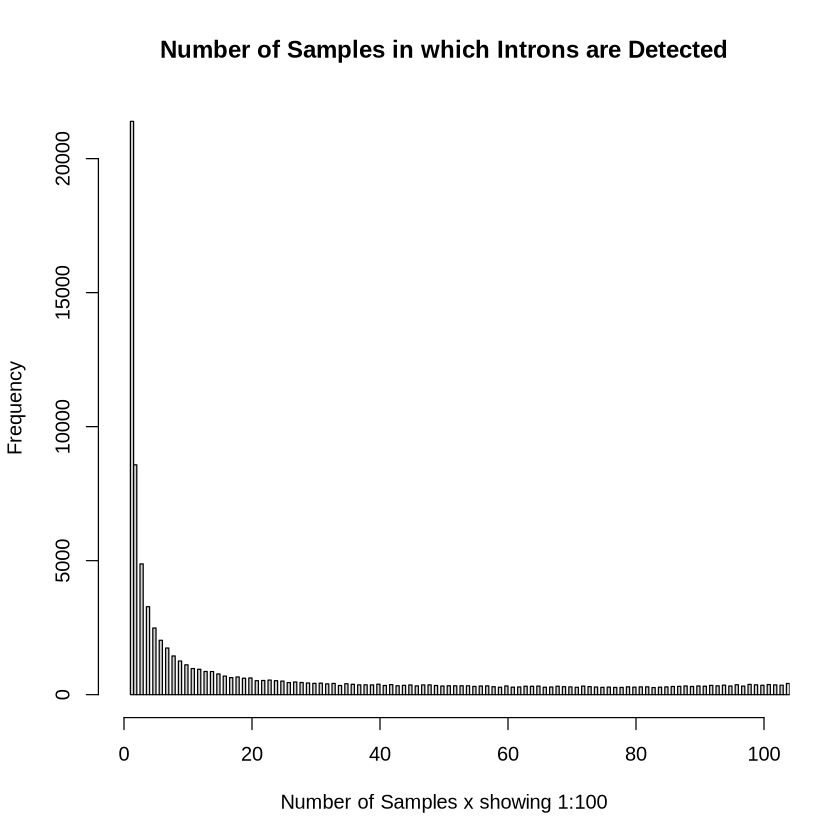

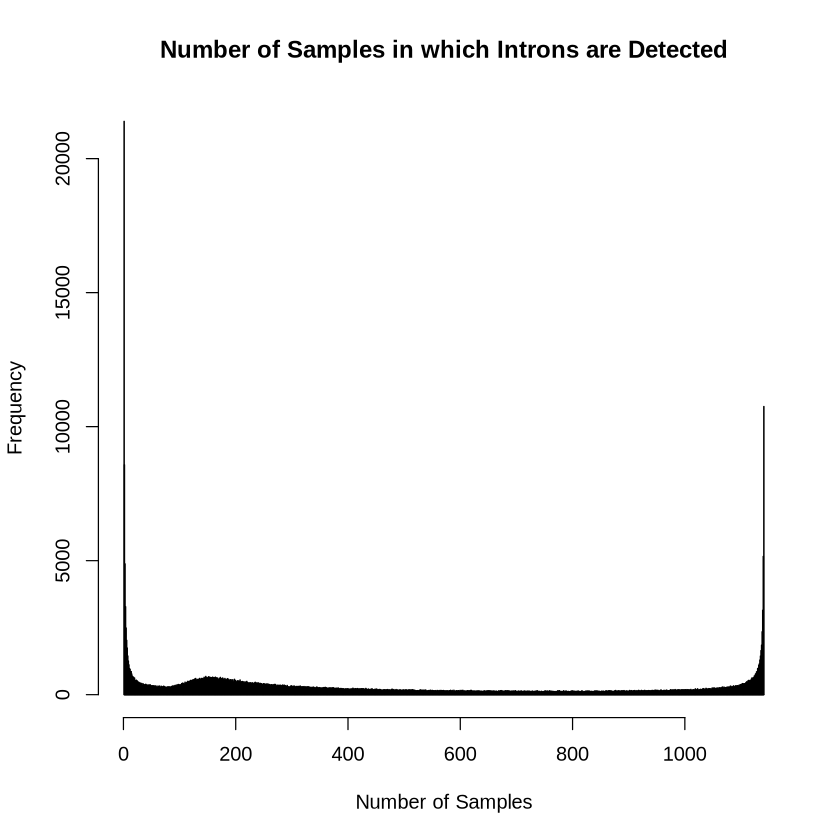

In [35]:
# step2
df_count <- df %>% 
  select(-1) %>% 
  apply(1, function(x) sum(x > 0)) 
hist(df_count, breaks = 3000, main = "Number of Samples in which Introns are Detected", xlab = "Number of Samples x showing 1:100", xlim = c(0,100))
hist(df_count, breaks = 3000, main = "Number of Samples in which Introns are Detected", xlab = "Number of Samples")


## filter raw data with min `m` samples with at least `n` reads each

[1] 364224

[1] 317136

[1] 0.8707169

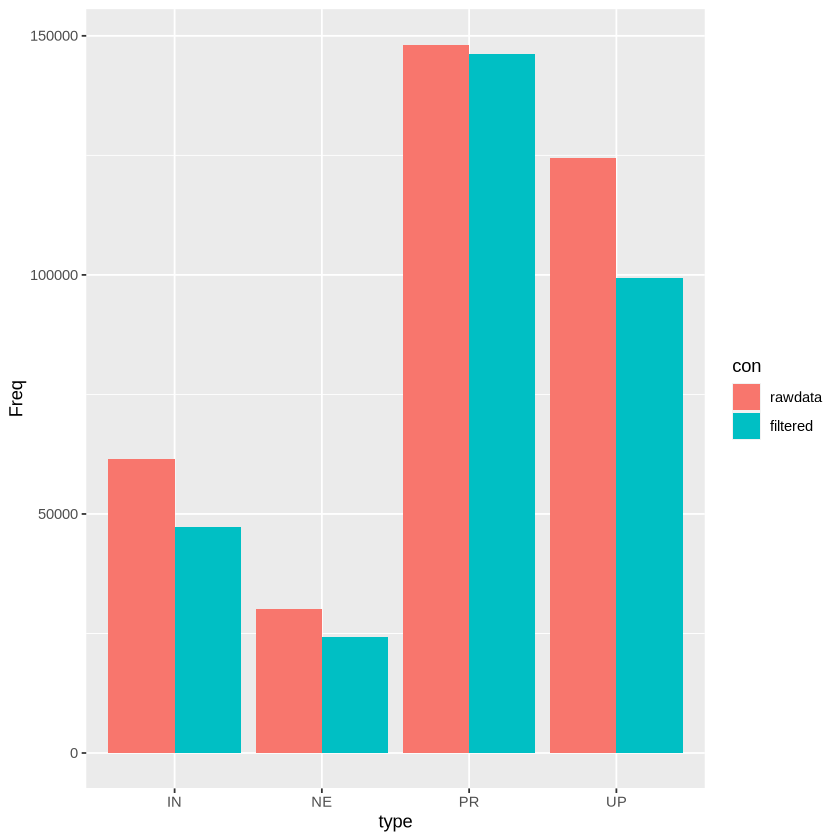

In [36]:
min_count = 1
min_sample = 10
#filter raw data with min 10 samples with at least 5 reads each
# Assuming 'df' is your dataframe with the first column being intron information and the rest being sample counts

# Step 1: Create a logical matrix where TRUE indicates that the intron has at least 5 reads in a sample
# logical_matrix <- df %>% 
#   select(-1) %>%
#   map_df(~.x >= 5)
logical_matrix <- as.data.frame(apply(df[,-1], 2, function(x) x >= min_count))

# Step 2: Sum the logical matrix by row to get the number of samples with at least 5 reads for each intron
samples_with_min_reads <- rowSums(logical_matrix)

# Step 3: Filter introns that are present in at least 10 samples with at least 5 reads
introns_to_keep <- which(samples_with_min_reads >= min_sample)

# Step 4: Subset the dataframe to keep only the desired introns
filtered_df <- df[introns_to_keep, ]

nrow(df)
nrow(filtered_df)
nrow(filtered_df)/nrow(df)

# Now 'filtered_df' contains only the introns that are present in at least 10 samples with at least 5 reads each
type_info1<- (df$chrom %>% str_split(.,":",simplify = T) %>% .[,5] %>% table)
type_info1 <- type_info1 %>% as.data.frame%>% mutate(con = "rawdata")

type_info2 <- (filtered_df$chrom %>% str_split(.,":",simplify = T) %>% .[,5] %>% table)
type_info2 <- type_info2 %>% as.data.frame%>% mutate(con = "filtered")

type_info <- rbind(type_info1,type_info2)
colnames(type_info)[1]<- 'type'
type_info$con <- factor(type_info$con,levels = c("rawdata","filtered"))
library(ggplot2)

ggplot(type_info, aes(x=type, y= Freq,group=con,  fill= con))+
  geom_bar(stat='identity',position = position_dodge())

In [37]:
filtered_df <- filtered_df %>% select(-DLPFC_samples_list_bam_list_intron_usage_perind.junc) #DLPFC_samples_list_bam_list_intron_usage_perind.junc is the list file should not be included
filtered_counts <- counts %>% filter(chrom %in% filtered_df$chrom) %>% select(-DLPFC_samples_list_bam_list_intron_usage_perind.junc)

In [2]:
filtered_df <- fread('/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind_numers.counts.noise_by_intron.QCed_minc1_mins10.gz')

In [3]:
filtered_counts <- counts %>% filter(chrom %in% filtered_df$chrom) %>% select(-DLPFC_samples_list_bam_list_intron_usage_perind.junc)
fwrite(filtered_counts, "/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind.counts.noise_by_intron.QCed_minc1_mins10.gz", sep = ' ')

In [7]:
fwrite(filtered_df, "/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind_numers.counts.noise_by_intron.QCed_minc1_mins10.gz", sep = ' ')
fwrite(filtered_counts, "/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind.counts.noise_by_intron.QCed_minc1_mins10.gz", sep = ' ')

## add constitutive introns 

In [38]:
library(data.table)
library(dplyr)
library(ggplot2)
library(tidyr)

# Function to calculate ECDF data
calculate_ecdf <- function(df, min_reads_cutoffs, dataset_name) {
  cutoff_data <- lapply(min_reads_cutoffs, function(cutoff) {
    df %>%
      select(-1) %>%
      apply(1, function(x) sum(x >= cutoff))
  })
  
  ecdf_data <- map_df(min_reads_cutoffs, function(cutoff, data) {
    tibble(
      sample_count = data[[which(min_reads_cutoffs == cutoff)]],
      cutoff = as.factor(cutoff)
    )
  }, data = cutoff_data) %>%
    arrange(cutoff, sample_count) %>%
    group_by(cutoff) %>%
    mutate(ecdf = ecdf(sample_count)(sample_count), dataset = dataset_name)
  
  return(ecdf_data)
}

#### check counts cut off

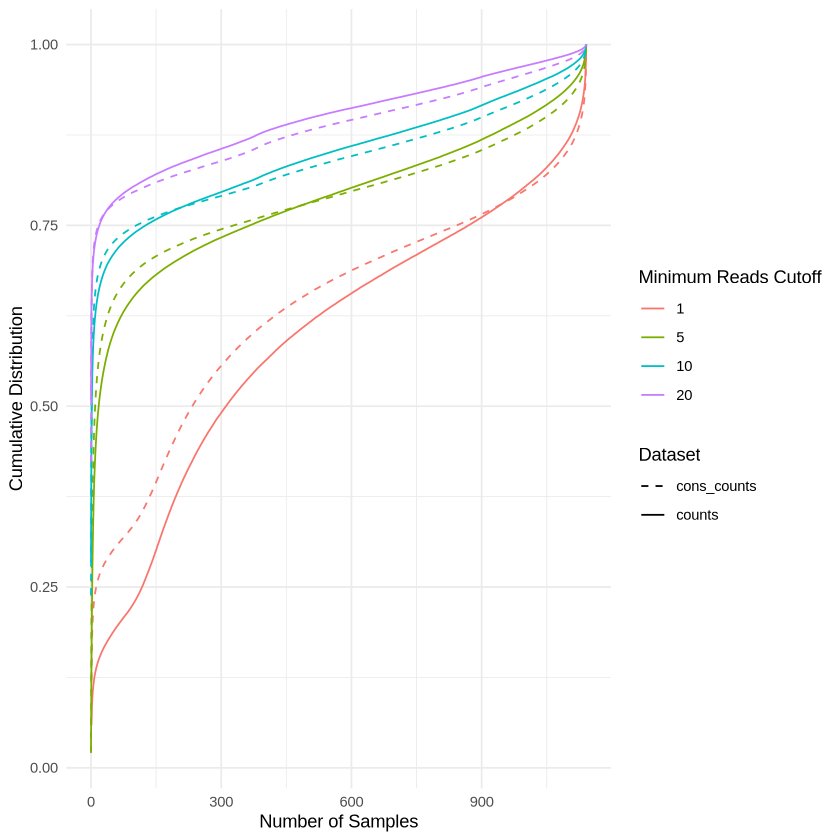

In [39]:
# Read in the data
nums_cons <- fread("/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2_const/ROSMAP_DLPFC_const_perind_numers.constcounts.noise_by_intron.gz")
#nums <- fread("~/Google Drive/My Drive/analysis/ROSMAP_DLPFC_perind_numers.counts.noise_by_intron.gz")

# Set cutoffs
min_reads_cutoffs <- c(1, 5, 10, 20) # Adjust as required

# Calculate ECDF for each dataset
ecdf_data1 <- calculate_ecdf(nums_cons, min_reads_cutoffs, 'cons_counts')
ecdf_data2 <- calculate_ecdf(nums, min_reads_cutoffs, 'counts')

# Combine the data
combined_ecdf_data <- rbind(ecdf_data1, ecdf_data2)

# Plot the ECDF
ggplot(combined_ecdf_data, aes(x = sample_count, y = ecdf, color = cutoff, linetype = dataset)) +
  geom_line() +
  labs(x = "Number of Samples", y = "Cumulative Distribution", color = "Minimum Reads Cutoff", linetype = "Dataset") +
  theme_minimal() +
  scale_linetype_manual(values = c("counts" = "solid", "cons_counts" = "dashed"))

In [41]:
ecdf_data2

sample_count,cutoff,ecdf,dataset
<int>,<fct>,<dbl>,<chr>
1,1,0.05873309,counts
1,1,0.05873309,counts
1,1,0.05873309,counts
1,1,0.05873309,counts
1,1,0.05873309,counts
1,1,0.05873309,counts
1,1,0.05873309,counts
1,1,0.05873309,counts
1,1,0.05873309,counts


#### check sample cut off

In [27]:
min_samples_threshold = 10

In [42]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(purrr)

# Function to calculate ECDF with feature removal based on sample percentage cutoffs
calculate_ecdf_with_feature_removal <- function(df, sample_percentage_cutoffs) {
  # Calculate the percentage of samples where count > 0 for each feature
  feature_presence <- df %>%
    select(-1) %>%
    apply(1, function(x) mean(x > 0))
  
  results <- lapply(sample_percentage_cutoffs, function(cutoff) {
    # Determine whether to retain the feature based on the sample percentage cutoff
    retained_features <- feature_presence >= cutoff / 100
    
    # Calculate the percentage of features dropped
    dropped_features_percentage <- mean(!retained_features)
    
    # Calculate ECDF for the retained features
    retained_counts <- df[retained_features, ] %>%
      select(-1) %>%
      apply(1, sum) # Assuming we're interested in the total counts for the retained features
    
    ecdf_data <- tibble(
      sum_count = retained_counts,
      cutoff = as.factor(cutoff)
    ) %>%
      mutate(ecdf = ecdf(sum_count)(sum_count))
    
    list(ecdf_data = ecdf_data, dropped_percentage = dropped_features_percentage)
  })
  
  # Combine ECDF data for all cutoffs
  ecdf_data_combined <- bind_rows(lapply(results, function(x) x$ecdf_data))
  # Extract dropped percentages for all cutoffs
  dropped_percentages <- sapply(results, function(x) x$dropped_percentage)
  
  # Return both ECDF data and dropped percentages
  list(ecdf_data = ecdf_data_combined, dropped_percentages = dropped_percentages)
}

# Example usage
# df <- read.csv("your_data.csv") # Load your data
sample_percentage_cutoffs <- c(1, 10, 20, 40) # Define sample percentage cutoffs
results <- calculate_ecdf_with_feature_removal(df, sample_percentage_cutoffs)

In [44]:
results$ecdf_data

sum_count,cutoff,ecdf
<int>,<fct>,<dbl>
12285,1,0.799846373
415,1,0.323807801
7338,1,0.750860186
957,1,0.501333130
659,1,0.430036058
8046,1,0.759481095
732,1,0.451124908
1241,1,0.545034407
1177,1,0.536553160


In [43]:
# Print the percentages of features dropped
print(results$dropped_percentages)

[1] 0.1350158 0.2451953 0.4181273 0.5933052


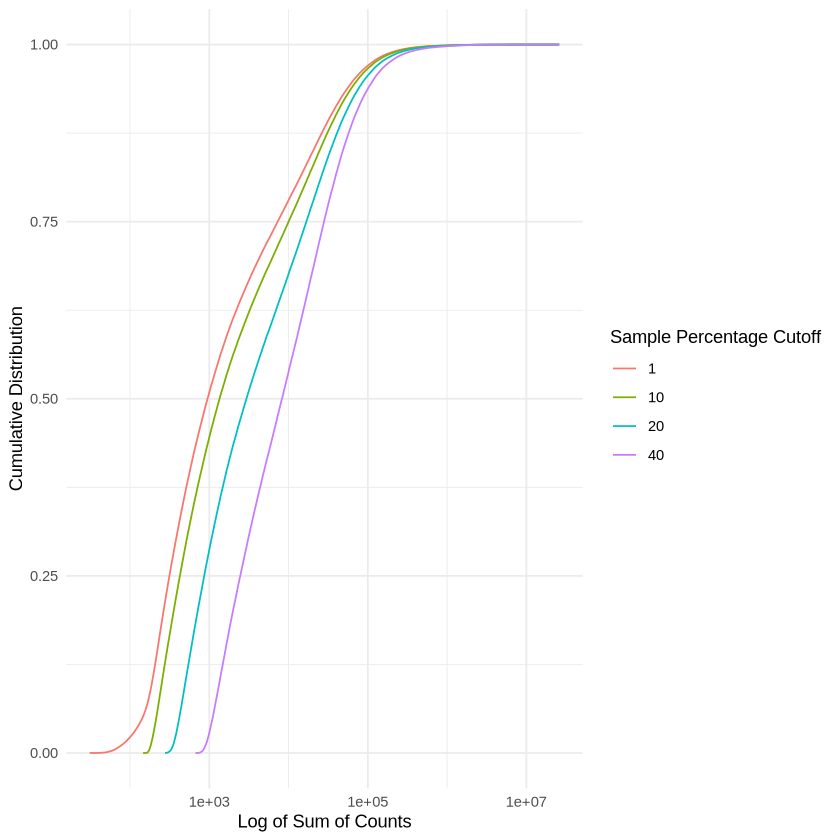

In [30]:
ggplot(results$ecdf_data, aes(x = sum_count, y = ecdf, color = cutoff)) +
  geom_line() +
  scale_x_log10() + # Apply log scale to x-axis
  labs(x = "Log of Sum of Counts", y = "Cumulative Distribution", color = "Sample Percentage Cutoff") +
  theme_minimal()


In [22]:
filtered_counts %>% head(n=200) %>% mutate(cluster_id = str_extract(chrom, "clu_\\d+"), 
                          category = str_extract(chrom, "([^:]+)(?=$)")) %>%
  group_by(cluster_id) %>%
  # Add a new column based on the condition
  mutate(cluster_status = ifelse(any(category %in% c("NE", "IN")), "no", "yes")) %>%
  # Filter rows where cluster_status is 'yes'
  filter(cluster_status == "yes")%>% 
  # Remove the cluster_status column
  select(-cluster_id,  -category, -cluster_status)                         

chrom,01_120405.Aligned.sortedByCoord.out_wasp_qc.md.junc,02_120405.Aligned.sortedByCoord.out_wasp_qc.md.junc,03_120405.Aligned.sortedByCoord.out_wasp_qc.md.junc,04_120405.Aligned.sortedByCoord.out_wasp_qc.md.junc,05_120405.Aligned.sortedByCoord.out_wasp_qc.md.junc,07_120410.Aligned.sortedByCoord.out_wasp_qc.md.junc,08_120410.Aligned.sortedByCoord.out_wasp_qc.md.junc,1000-DLPFC.Aligned.sortedByCoord.out_wasp_qc.md.junc,100_120417.Aligned.sortedByCoord.out_wasp_qc.md.junc,⋯,RISK_95.Aligned.sortedByCoord.out_wasp_qc.md.junc,RISK_97.Aligned.sortedByCoord.out_wasp_qc.md.junc,RISK_99.Aligned.sortedByCoord.out_wasp_qc.md.junc,RISK_9_rerun.Aligned.sortedByCoord.out_wasp_qc.md.junc,SM-2T6Z5.Aligned.sortedByCoord.out_wasp_qc.md.junc,SM-2T717.Aligned.sortedByCoord.out_wasp_qc.md.junc,SM-49KVA.Aligned.sortedByCoord.out_wasp_qc.md.junc,SM-AYO4G.Aligned.sortedByCoord.out_wasp_qc.md.junc,SM-AYOQN.Aligned.sortedByCoord.out_wasp_qc.md.junc,SM-AYOSS.Aligned.sortedByCoord.out_wasp_qc.md.junc
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
chr1:924948:925921:clu_44_+:PR,1/3,0/0,0/0,2/2,0/0,0/0,0/0,0/1,0/1,⋯,0/0,0/0,2/2,0/0,1/5,0/0,0/1,0/0,0/0,0/0
chr1:926013:930154:clu_44_+:PR,2/3,0/0,0/0,0/2,0/0,0/0,0/0,1/1,1/1,⋯,0/0,0/0,0/2,0/0,3/5,0/0,1/1,0/0,0/0,0/0
chr1:931089:935771:clu_45_+:PR,5/5,0/0,0/0,1/1,0/0,0/0,0/0,1/3,0/0,⋯,0/0,0/0,2/2,2/2,3/3,0/0,0/0,0/0,0/0,0/0
chr1:935896:939039:clu_46_+:PR,4/4,0/0,0/0,8/8,0/0,0/0,1/1,0/0,3/3,⋯,0/0,0/0,0/0,0/0,2/2,1/1,1/1,0/0,0/0,0/0
chr1:939129:939271:clu_48_+:PR,1/2,0/0,0/1,5/8,0/0,0/1,0/0,0/0,1/2,⋯,0/0,0/0,0/0,0/0,2/4,0/1,0/0,1/1,0/0,0/0
chr1:939129:939274:clu_48_+:PR,1/2,0/0,1/1,3/8,0/0,1/1,0/0,0/0,1/2,⋯,0/0,0/0,0/0,0/0,2/4,1/1,0/0,0/1,0/0,0/0
chr1:939412:941143:clu_49_+:PR,0/4,0/1,0/1,7/14,0/0,0/0,2/3,0/3,1/5,⋯,0/0,0/0,0/0,0/0,1/3,0/0,1/1,0/0,0/0,0/0
chr1:939460:941143:clu_49_+:PR,1/4,0/1,0/1,0/14,0/0,0/0,0/3,0/3,1/5,⋯,0/0,0/0,0/0,0/0,1/3,0/0,0/1,0/0,0/0,0/0
chr1:942251:942409:clu_49_+:PR,2/4,1/1,1/1,7/14,0/0,0/0,0/3,3/3,3/5,⋯,0/0,0/0,0/0,0/0,1/3,0/0,0/1,0/0,0/0,0/0


### cluster count filter

#### generate cluster counts

In [ ]:
library(data.table)
library(tidyverse)
counts <- fread("/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind.counts.noise_by_intron.gz")
# counts_raw = counts

In [ ]:
counts <- counts %>% mutate(cluster_id = str_extract(counts$chrom, "clu_\\d+")) %>% distinct(cluster_id, .keep_all = TRUE)

In [ ]:
setDT(counts)[, (2:(ncol(counts)-1)) := lapply(.SD, function(x) sapply(strsplit(x, "/"), function(y) y[2])), .SDcols = 2:(ncol(counts)-1)]

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks data.table::transpose()
✖ lubridate::wday() 

In [ ]:
 counts %>% mutate(chrom = cluster_id) %>% select(-ncol(.)) %>% rename(clu_id = chrom) %>% fwrite(., '/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind.counts.noise_by_intron.cluster.count.gz', sep = ' ')

In [2]:
# Read in the data
df <- data.table::fread("/mnt/vast/hpc/csg/rf2872/Work/leaf_cutter2/ROSMAP_DLPFC_2024/output/leafcutter2/ROSMAP_DLPFC_perind.counts.noise_by_intron.cluster.count.gz")



In [4]:
dim(df)

[1] 120988   1143

In [5]:
# For each event, how many samples with count > cutoff. 
min_reads_cutoffs = 1
cutoff_data <- lapply(min_reads_cutoffs, function(cutoff) {
    df %>%
      select(-1) %>%
      apply(1, function(x) sum(x >= cutoff))
  })

In [6]:
str(cutoff_data[[1]])

 int [1:120988] 29 38 721 474 60 22 101 16 31 82 ...


In [7]:
# Dimension and range of cutoff-data
length(cutoff_data[[1]]); range(cutoff_data[[1]])

[1] 120988

[1]    1 1141

#### filering based on that 
 I want to check how the proportion of the sample with count as 0 for each feature(event), and get the ecdf for 1 sample 

In [8]:
# cutoff = 0.01
sample_count_01 <- cutoff_data[[1]][cutoff_data[[1]] >= 0.01 * 1141]
length(sample_count_01); range(sample_count_01)

head(table(sample_count_01))

# this is the theoritical ecdf shown in your figure (curve) with cutoff=1
ecdf_xc_01 <- cumsum(table(sample_count_01)) / length(sample_count_01)
head(ecdf_xc_01)
length(ecdf_xc_01) 

[1] 114407

[1]   12 1141

sample_count_01
 12  13  14  15  16  17 
353 342 286 268 251 247 

12          13          14          15          16          17 
0.003085476 0.006074803 0.008574650 0.010917164 0.013111086 0.015270045

[1] 1130

In [9]:
# cutoff= 0.1
sample_count_1 <- cutoff_data[[1]][cutoff_data[[1]] >= 0.1 * 1141]
length(sample_count_1); range(sample_count_1)

head(table(sample_count_1))

# this is the theoritical ecdf shown in your figure (curve) with cutoff=1
ecdf_xc_1  <- cumsum(table(sample_count_1)) / length(sample_count_1)
head(ecdf_xc_1)
length(ecdf_xc_1) 

[1] 104720

[1]  115 1141

sample_count_1
115 116 117 118 119 120 
 56  47  37  36  45  59 

115          116          117          118          119          120 
0.0005347594 0.0009835752 0.0013368984 0.0016806723 0.0021103896 0.0026737968

[1] 1027

In [10]:
# cutoff = 0.2
sample_count_2 <- cutoff_data[[1]][cutoff_data[[1]] >= 0.2 * 1141]
length(sample_count_2); range(sample_count_2)

head(table(sample_count_2))

# this is the theoritical ecdf shown in your figure (curve) with cutoff=1
ecdf_xc_2 <- cumsum(table(sample_count_2)) / length(sample_count_2)
head(ecdf_xc_2)
length(ecdf_xc_2) 

[1] 96606

[1]  229 1141

sample_count_2
229 230 231 232 233 234 
 80  73  90  85  89  76 

229          230          231          232          233          234 
0.0008281059 0.0015837526 0.0025153717 0.0033952343 0.0043165021 0.0051032027

[1] 913

In [11]:
# cutoff = 0.4
sample_count_4 <- cutoff_data[[1]][cutoff_data[[1]]>= 0.4 * 1141]
length(sample_count_4); range(sample_count_4)

head(table(sample_count_4))

# this is the theoritical ecdf shown in your figure (curve) with cutoff=1
ecdf_xc_4 <- cumsum(table(sample_count_4)) / length(sample_count_4)
head(ecdf_xc_4)
length(ecdf_xc_4) 

[1] 81036

[1]  457 1141

sample_count_4
457 458 459 460 461 462 
 54  53  48  45  46  58 

457          458          459          460          461          462 
0.0006663705 0.0013204008 0.0019127301 0.0024680389 0.0030356878 0.0037514191

[1] 685

In [12]:
all_ecdf <- rbind( ecdf_xc_01 %>% as.data.frame %>% setNames(c('ecdf')) %>% mutate(sample_count = names(ecdf_xc_01), sam_cutoff = 0.01),
            ecdf_xc_1 %>% as.data.frame %>% setNames(c('ecdf')) %>% mutate(sample_count = names(ecdf_xc_1), sam_cutoff = 0.1),
            ecdf_xc_2 %>% as.data.frame %>% setNames(c('ecdf')) %>% mutate(sample_count = names(ecdf_xc_2), sam_cutoff = 0.2),
            ecdf_xc_4 %>% as.data.frame %>% setNames(c('ecdf')) %>% mutate(sample_count = names(ecdf_xc_4), sam_cutoff = 0.4))

In [13]:
all_ecdf$sample_count <- as.numeric(all_ecdf$sample_count)
all_ecdf$sam_cutoff <- as.factor(all_ecdf$sam_cutoff)

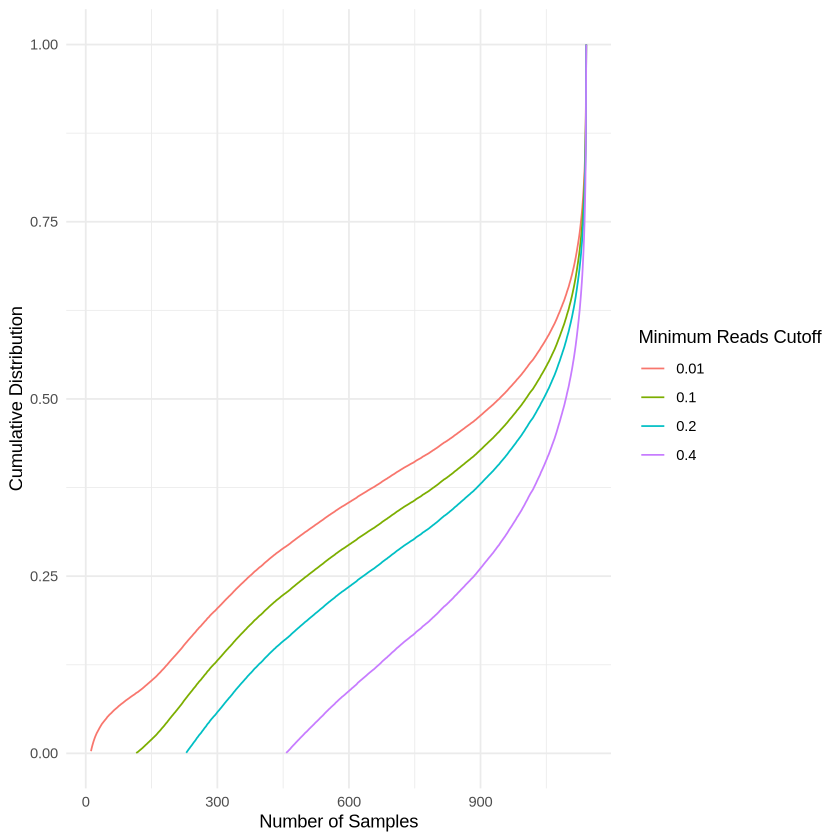

In [14]:
library(ggplot2)
ggplot(all_ecdf, aes(x = sample_count, y = ecdf, color = sam_cutoff)) +
  geom_line() +
  labs(x = "Number of Samples", y = "Cumulative Distribution", color = "Minimum Reads Cutoff") +
  theme_minimal()